# Retail Demand Forecasting

## 3. Exploratory Data Analysis

This stage examines historical retail demand to identify temporal patterns, seasonal behaviour, differences across stores and product families, and the influence of promotional and external factors.

The analysis is designed to support subsequent feature engineering and forecasting model development.

### Key Questions

- How has overall demand evolved over time?
- What daily, weekly, monthly, and yearly seasonal patterns exist?
- Which stores and product families contribute most to total sales?
- How strongly are promotions associated with sales?
- Do holidays influence demand?
- What relationship exists between transactions and sales?
- Does the external oil price provide useful information about demand?
- Which segments exhibit high demand volatility?

In [16]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

In [17]:
DATA_PATH = "data/processed_sales_data.csv"

df = pd.read_csv(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(
    ["date", "store_nbr", "family"]
).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")

Dataset shape: (3000888, 13)


In [18]:
df.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico,transactions,is_holiday
0,0,2013-01-01,1,AUTOMOTIVE,0.00,0,Quito,Pichincha,D,13,NaN,NaN,1
1,1,2013-01-01,1,BABY CARE,0.00,0,Quito,Pichincha,D,13,NaN,NaN,1
2,2,2013-01-01,1,BEAUTY,0.00,0,Quito,Pichincha,D,13,NaN,NaN,1
3,3,2013-01-01,1,BEVERAGES,0.00,0,Quito,Pichincha,D,13,NaN,NaN,1
4,4,2013-01-01,1,BOOKS,0.00,0,Quito,Pichincha,D,13,NaN,NaN,1


## 3.2 Temporal Analysis

Temporal patterns are examined to identify long-term trends, recurring seasonal behaviour, and calendar effects that may influence future demand.

The analysis considers annual, monthly, weekly, and weekday-level sales patterns.

In [19]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.month_name()
df["day_of_week"] = df["date"].dt.dayofweek
df["day_name"] = df["date"].dt.day_name()
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["quarter"] = df["date"].dt.quarter
df["is_weekend"] = df["day_of_week"].isin([5, 6])

## 3.3 Overall Sales Trend

Daily total sales are aggregated across all stores and product families to examine the overall evolution of retail demand throughout the historical period.

In [20]:
daily_sales = (
    df.groupby("date", as_index=False)["sales"]
    .sum()
)

daily_sales.head()

,date,sales
0,2013-01-01,"2,511.62"
1,2013-01-02,"496,092.42"
2,2013-01-03,"361,461.23"
3,2013-01-04,"354,459.68"
4,2013-01-05,"477,350.12"


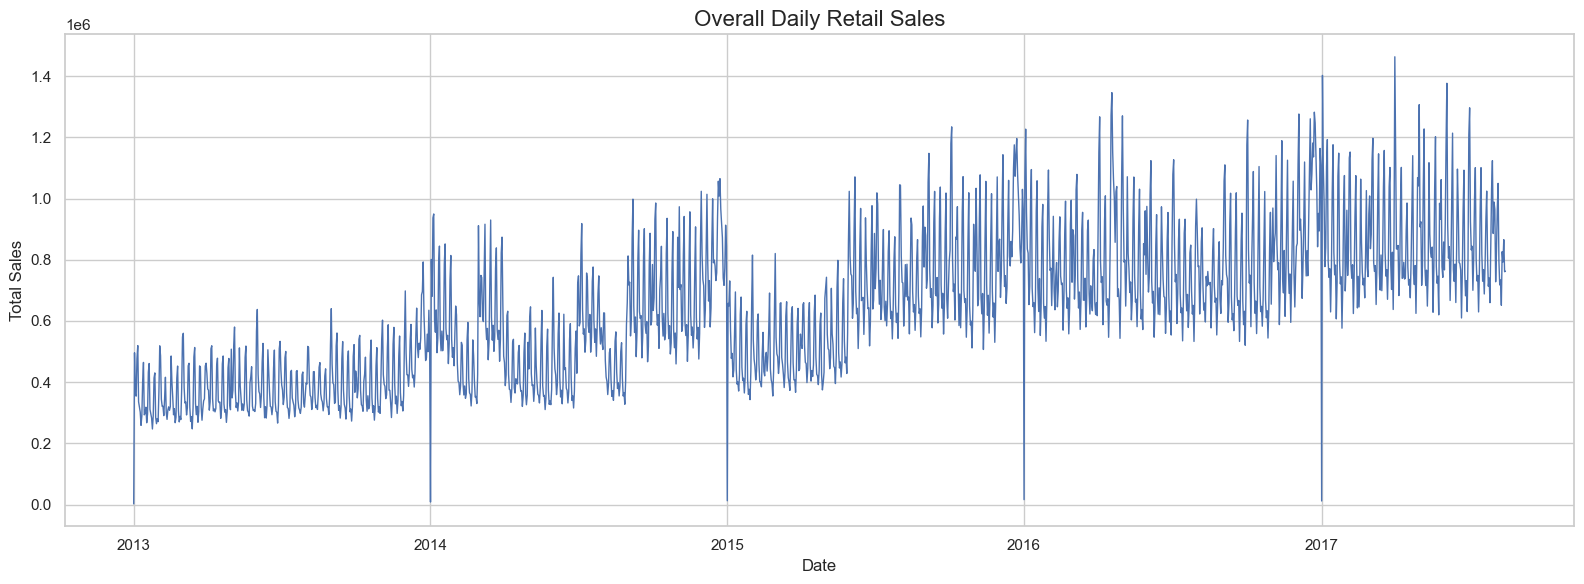

In [21]:
plt.figure(figsize=(16, 6))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"],
    linewidth=1
)

plt.title("Overall Daily Retail Sales", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

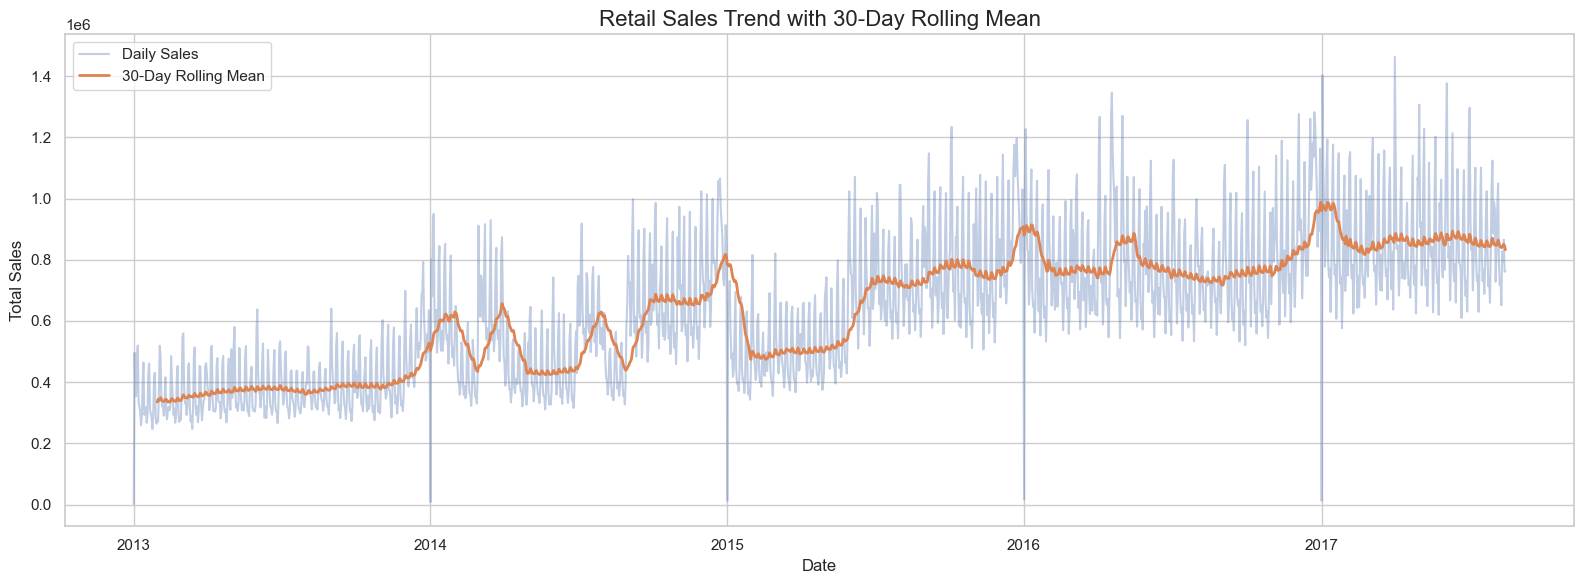

In [22]:
daily_sales["rolling_30"] = (
    daily_sales["sales"]
    .rolling(30)
    .mean()
)

plt.figure(figsize=(16, 6))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"],
    alpha=0.35,
    label="Daily Sales"
)

plt.plot(
    daily_sales["date"],
    daily_sales["rolling_30"],
    linewidth=2,
    label="30-Day Rolling Mean"
)

plt.title("Retail Sales Trend with 30-Day Rolling Mean", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.tight_layout()
plt.show()

## 3.4 Annual Sales Trend

Annual sales are compared to identify changes in overall demand across years and to determine whether the business exhibits a long-term growth or decline pattern.

In [23]:
annual_sales = (
    df.groupby("year")["sales"]
    .agg(
        total_sales="sum",
        average_daily_sales=lambda x: x.sum() / df.loc[x.index, "date"].nunique()
    )
)

annual_sales

,total_sales,average_daily_sales
year,,
2013,"140,419,013.92","385,766.52"
2014,"209,474,246.30","575,478.70"
2015,"240,880,100.65","661,758.52"
2016,"288,654,522.95","790,834.31"
2017,"194,217,068.37","855,581.80"


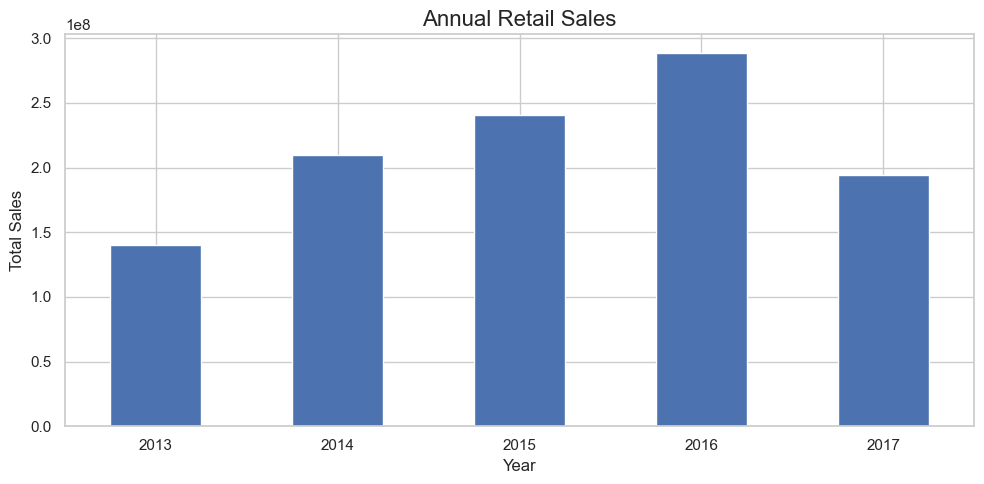

In [24]:
annual_total = (
    df.groupby("year")["sales"]
    .sum()
)

plt.figure(figsize=(10, 5))

annual_total.plot(kind="bar")

plt.title("Annual Retail Sales", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3.5 Monthly Seasonality

Average sales are examined by calendar month to identify recurring annual seasonal patterns.

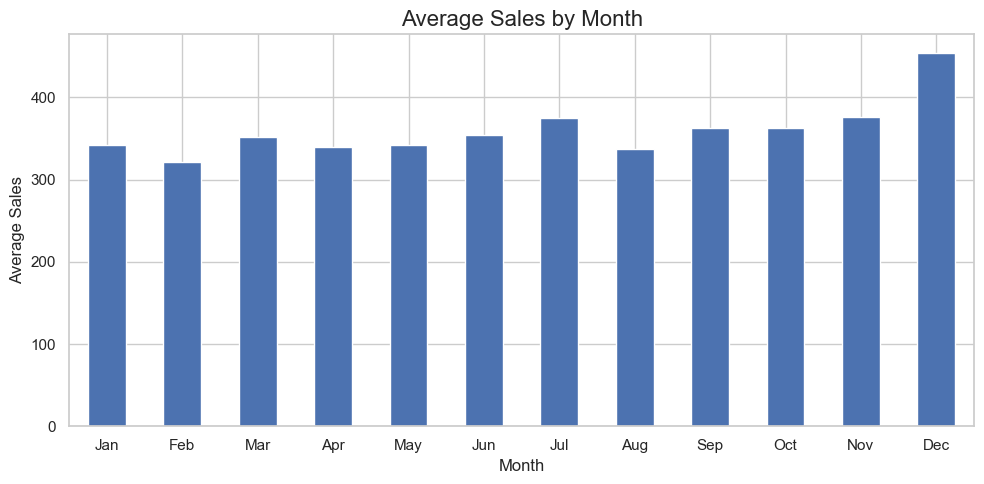

In [25]:
monthly_pattern = (
    df.groupby("month")["sales"]
    .mean()
)

plt.figure(figsize=(10, 5))

monthly_pattern.plot(
    kind="bar"
)

plt.title("Average Sales by Month", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(range(12), [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
], rotation=0)

plt.tight_layout()
plt.show()

## 3.6 Monthly Sales Across Years

Monthly sales are compared across years to distinguish recurring seasonal behaviour from broader changes in demand.

In [26]:
monthly_yearly = (
    df.groupby(["year", "month"])["sales"]
    .sum()
    .reset_index()
)

monthly_yearly_pivot = monthly_yearly.pivot(
    index="month",
    columns="year",
    values="sales"
)

monthly_yearly_pivot

year,2013,2014,2015,2016,2017
month,,,,,
1,"10,327,624.74","18,911,640.70","14,896,922.06","23,977,804.89","26,328,159.94"
2,"9,658,959.78","12,038,352.63","13,742,395.85","21,947,408.80","23,250,112.37"
3,"11,428,497.04","20,365,584.02","15,598,607.52","23,131,780.88","26,704,017.69"
4,"10,993,464.74","12,861,251.06","14,955,068.17","25,963,025.10","25,895,308.49"
5,"11,597,704.01","13,379,785.26","17,730,368.24","24,779,432.26","26,911,847.25"
6,"11,689,344.06","13,319,958.17","21,615,360.35","22,209,218.58","25,682,822.12"
7,"11,257,400.61","19,421,891.04","22,209,619.04","23,462,672.43","27,011,477.57"
8,"11,737,788.92","13,885,176.42","22,963,674.24","22,452,414.32","12,433,322.94"
9,"11,792,933.23","20,022,416.11","23,240,882.48","22,417,448.10",NaN


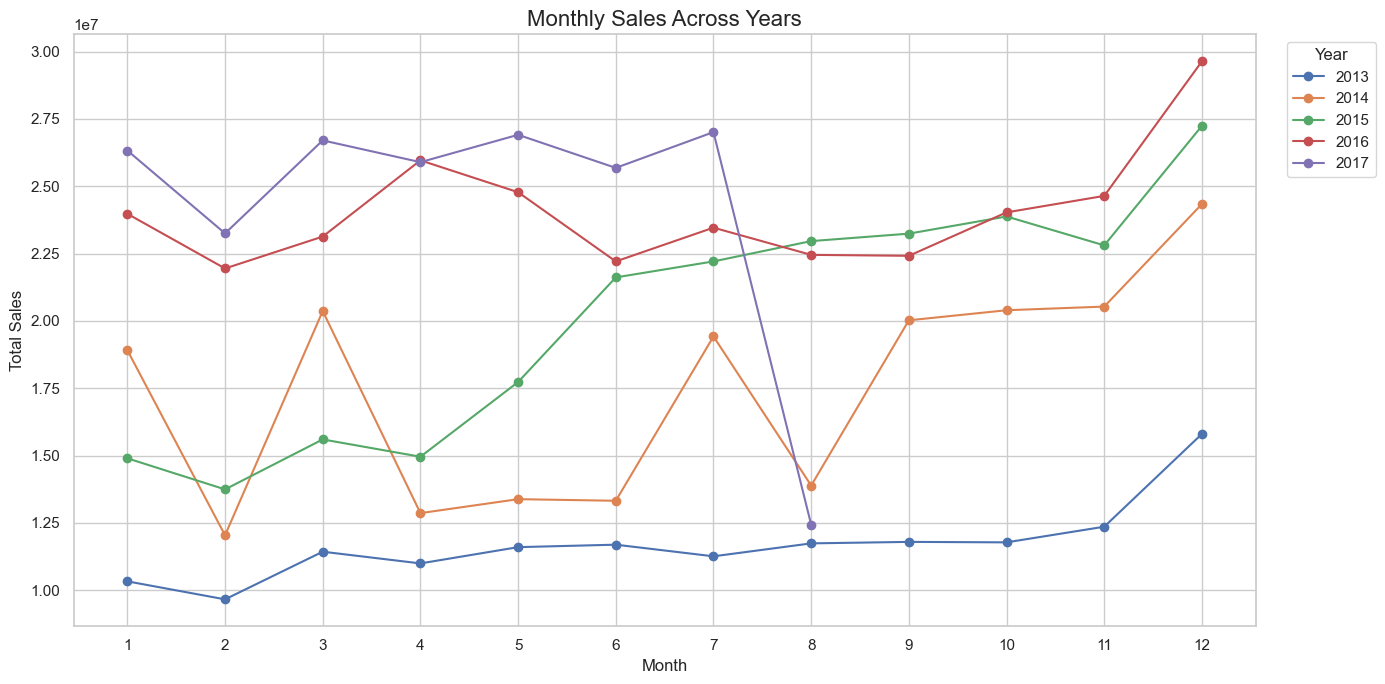

In [27]:
plt.figure(figsize=(14, 7))

for year in monthly_yearly_pivot.columns:
    plt.plot(
        monthly_yearly_pivot.index,
        monthly_yearly_pivot[year],
        marker="o",
        label=str(year)
    )

plt.title("Monthly Sales Across Years", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13))
plt.legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 3.7 Weekly Seasonality

Average demand is evaluated by day of week to identify recurring weekly patterns that can be incorporated into forecasting models.

In [28]:
weekly_pattern = (
    df.groupby("day_of_week")["sales"]
    .mean()
)

day_labels = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekly_pattern.index = day_labels

weekly_pattern

Monday      346.54
Tuesday     319.82
Wednesday   332.91
Thursday    283.54
Friday      325.24
Saturday    433.34
Sunday      463.09
Name: sales, dtype: float64

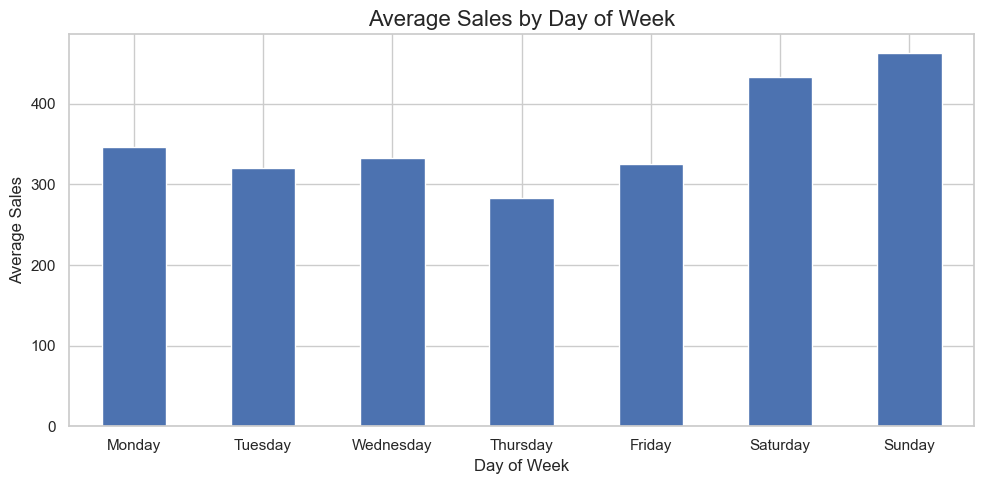

In [29]:
plt.figure(figsize=(10, 5))

weekly_pattern.plot(kind="bar")

plt.title("Average Sales by Day of Week", fontsize=16)
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3.8 Weekday and Weekend Demand

Average demand during weekdays and weekends is compared to determine whether the forecasting system should explicitly account for weekend effects.

In [30]:
weekend_summary = (
    df.groupby("is_weekend")["sales"]
    .agg(
        average_sales="mean",
        median_sales="median",
        total_sales="sum"
    )
)

weekend_summary.index = ["Weekday", "Weekend"]

weekend_summary

,average_sales,median_sales,total_sales
Weekday,321.63,10.00,"689,491,054.88"
Weekend,448.18,13.00,"384,153,897.32"


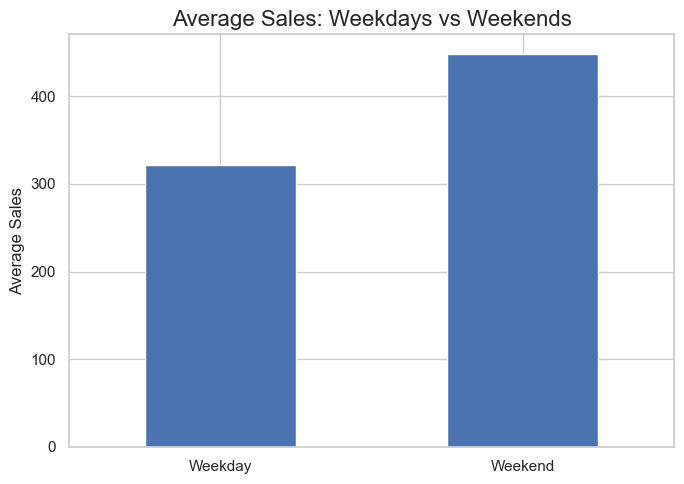

In [31]:
plt.figure(figsize=(7, 5))

weekend_summary["average_sales"].plot(kind="bar")

plt.title("Average Sales: Weekdays vs Weekends", fontsize=16)
plt.xlabel("")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3.9 Store-Level Demand

Demand is compared across stores to identify differences in sales volume and demand variability between locations.

In [32]:
store_sales = (
    df.groupby("store_nbr")["sales"]
    .agg(
        total_sales="sum",
        average_sales="mean",
        median_sales="median",
        sales_std="std"
    )
    .sort_values("total_sales", ascending=False)
)

store_sales.head(10)

,total_sales,average_sales,median_sales,sales_std
store_nbr,,,,
44,"62,087,553.25","1,117.25",75.00,"2,685.28"
45,"54,498,010.42",980.67,62.00,"2,384.32"
47,"50,948,310.06",916.80,51.00,"2,222.32"
3,"50,481,910.19",908.41,64.00,"2,146.19"
49,"43,420,095.78",781.33,48.00,"1,897.86"
46,"41,896,062.12",753.91,36.00,"1,889.01"
48,"35,933,130.27",646.60,30.00,"1,668.49"
51,"32,911,489.54",592.23,27.00,"1,352.21"
8,"30,494,286.93",548.73,39.00,"1,275.42"


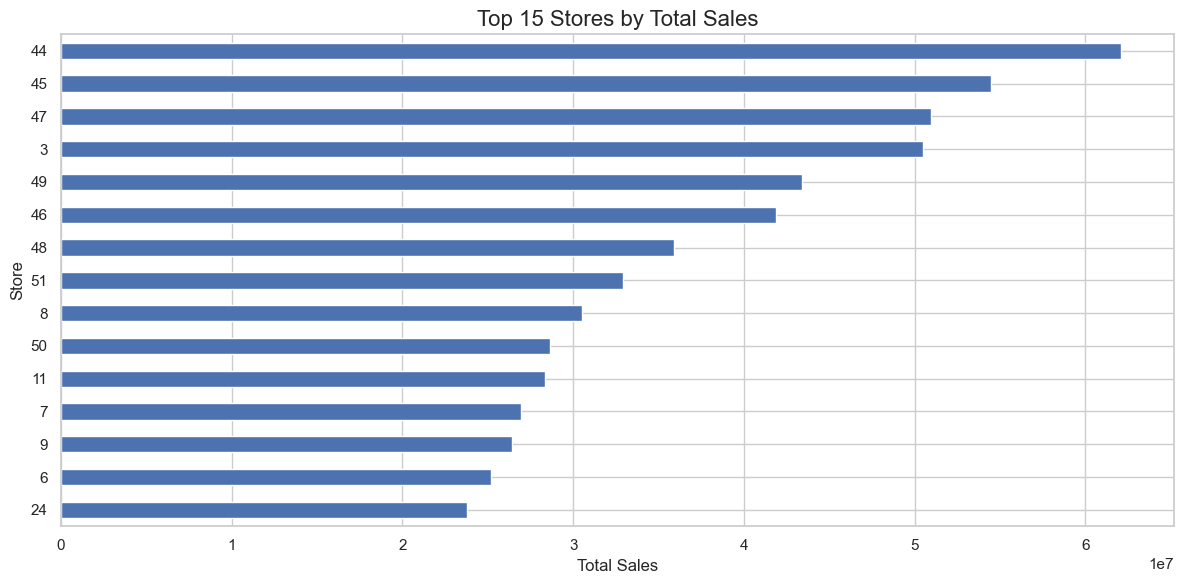

In [33]:
plt.figure(figsize=(12, 6))

store_sales["total_sales"].head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Stores by Total Sales", fontsize=16)
plt.xlabel("Total Sales")
plt.ylabel("Store")
plt.tight_layout()
plt.show()

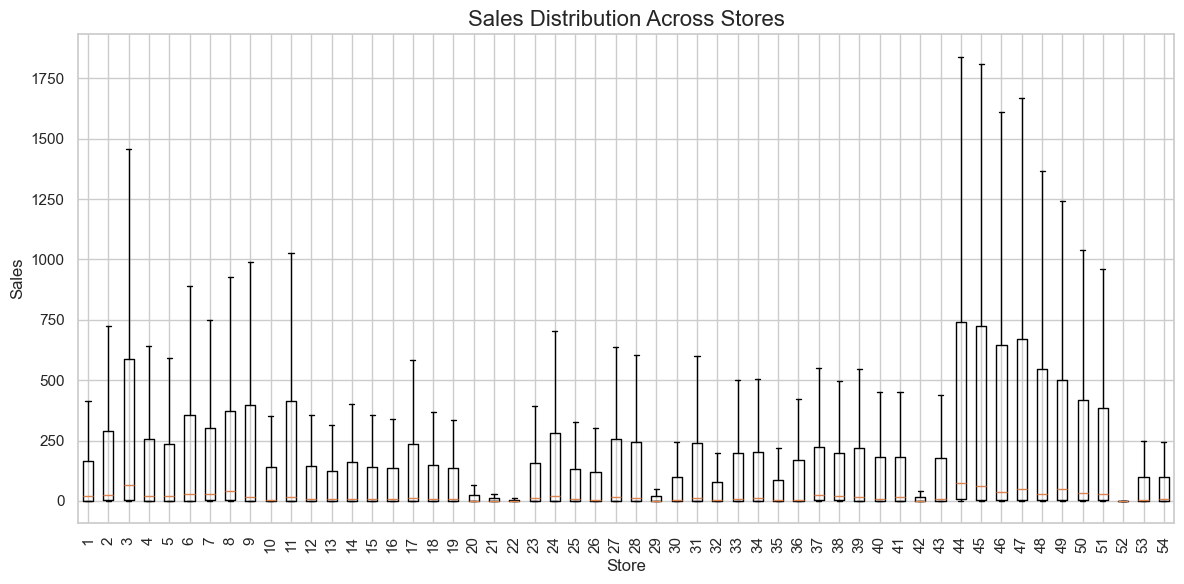

In [34]:
plt.figure(figsize=(12, 6))

plt.boxplot(
    [
        df.loc[df["store_nbr"] == store, "sales"]
        for store in sorted(df["store_nbr"].unique())
    ],
    labels=sorted(df["store_nbr"].unique()),
    showfliers=False
)

plt.title("Sales Distribution Across Stores", fontsize=16)
plt.xlabel("Store")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 3.10 Product Family Demand

Sales are examined across product families to identify the major contributors to overall demand and differences in demand intensity between product categories.

In [35]:
family_sales = (
    df.groupby("family")["sales"]
    .agg(
        total_sales="sum",
        average_sales="mean",
        median_sales="median",
        sales_std="std"
    )
    .sort_values("total_sales", ascending=False)
)

family_sales

,total_sales,average_sales,median_sales,sales_std
family,,,,
GROCERY I,"343,462,734.89","3,776.97","3,185.00","2,874.21"
BEVERAGES,"216,954,486.00","2,385.79","1,784.00","2,307.88"
PRODUCE,"122,704,684.68","1,349.35",398.29,"2,186.48"
CLEANING,"97,521,289.00","1,072.42",938.00,734.68
DAIRY,"64,487,709.00",709.15,520.00,671.95
BREAD/BAKERY,"42,133,945.58",463.34,401.00,368.25
POULTRY,"31,876,004.47",350.53,205.74,400.51
MEATS,"31,086,468.40",341.85,224.94,455.91
PERSONAL CARE,"24,592,051.00",270.43,222.00,226.51


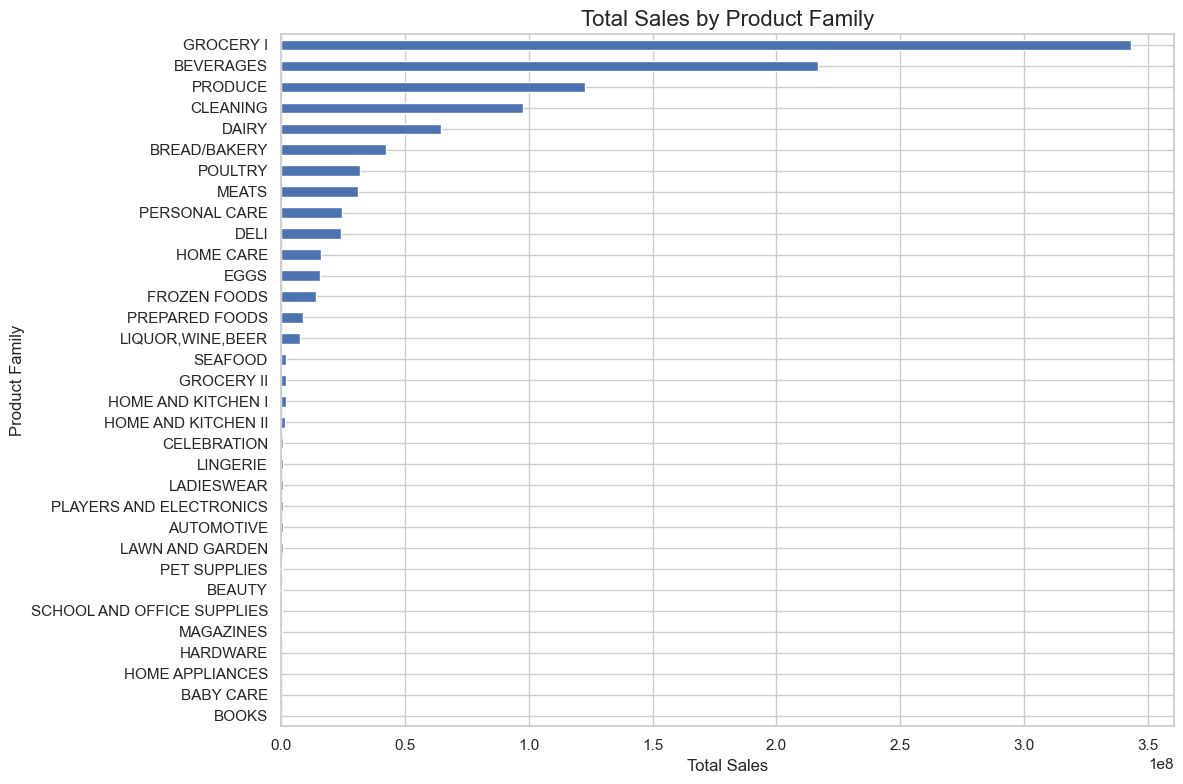

In [36]:
plt.figure(figsize=(12, 8))

family_sales["total_sales"].sort_values().plot(
    kind="barh"
)

plt.title("Total Sales by Product Family", fontsize=16)
plt.xlabel("Total Sales")
plt.ylabel("Product Family")
plt.tight_layout()
plt.show()

## 3.11 Promotion Analysis

Promotional activity is evaluated as a potential demand driver by comparing sales behaviour during periods with and without promotions.

In [37]:
promotion_summary = (
    df.groupby("onpromotion")["sales"]
    .agg(
        average_sales="mean",
        median_sales="median",
        total_sales="sum",
        observations="count"
    )
)

promotion_summary

,average_sales,median_sales,total_sales,observations
onpromotion,,,,
0,158.25,3.00,"378,139,781.74",2389559
1,467.56,145.35,"81,612,460.22",174551
2,662.93,245.31,"52,627,014.23",79386
3,871.41,325.39,"39,964,517.93",45862
4,969.92,346.00,"30,706,574.93",31659
...,...,...,...,...
719,"6,681.00","6,681.00","6,681.00",1
720,"6,154.00","6,154.00","6,154.00",1
722,"5,846.00","5,846.00","5,846.00",1


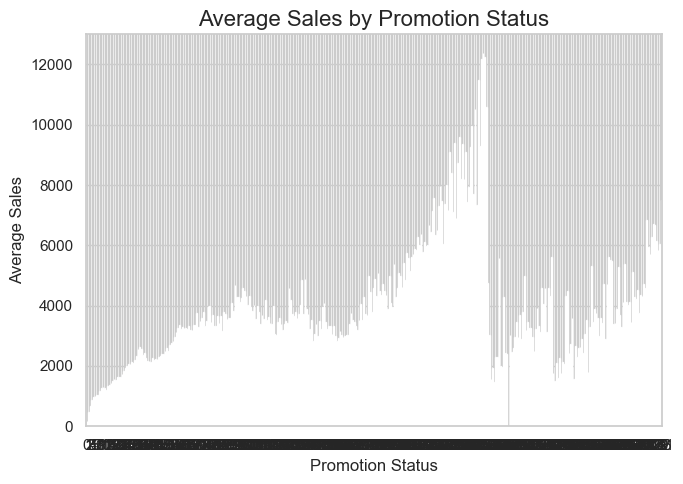

In [38]:
plt.figure(figsize=(7, 5))

promotion_summary["average_sales"].plot(kind="bar")

plt.title("Average Sales by Promotion Status", fontsize=16)
plt.xlabel("Promotion Status")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

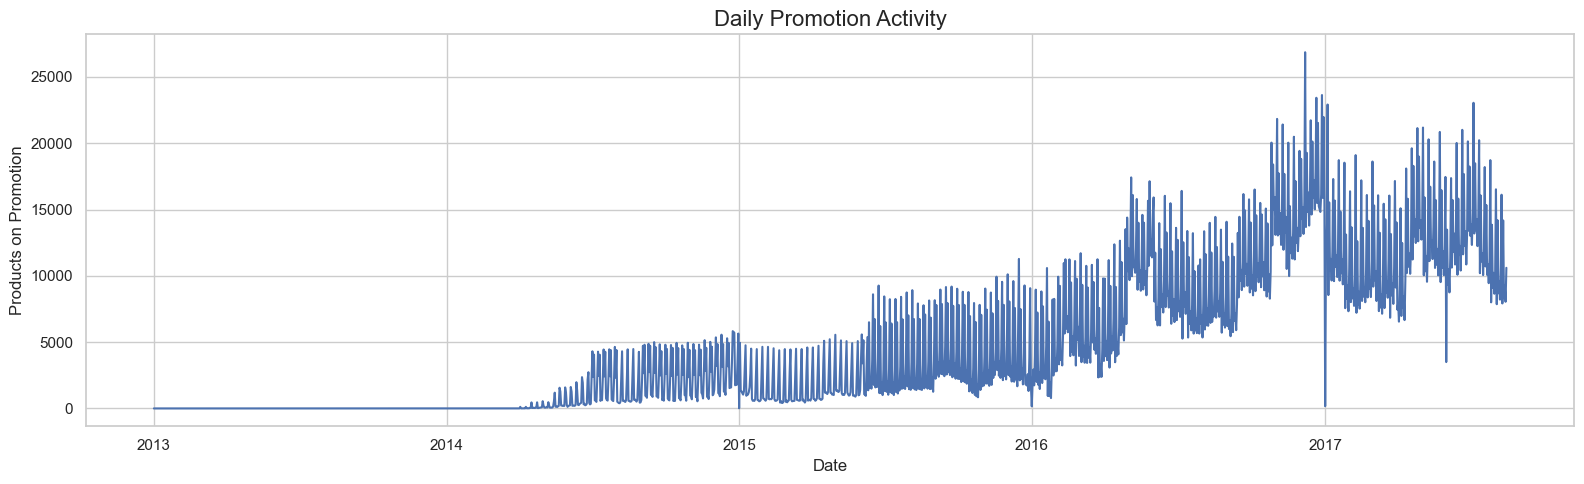

In [39]:
daily_promotion = (
    df.groupby("date")["onpromotion"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(16, 5))

plt.plot(
    daily_promotion["date"],
    daily_promotion["onpromotion"]
)

plt.title("Daily Promotion Activity", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Products on Promotion")
plt.tight_layout()
plt.show()

## 3.12 Holiday Demand

Holiday periods are compared with non-holiday periods to determine whether calendar events represent a meaningful demand signal.

In [40]:
holiday_summary = (
    df.groupby("is_holiday")["sales"]
    .agg(
        average_sales="mean",
        median_sales="median",
        total_sales="sum",
        observations="count"
    )
)

holiday_summary.index = [
    "Non-Holiday",
    "Holiday"
]

holiday_summary

,average_sales,median_sales,total_sales,observations
Non-Holiday,351.91,11.00,"903,645,051.72",2567862
Holiday,392.59,12.00,"169,999,900.49",433026


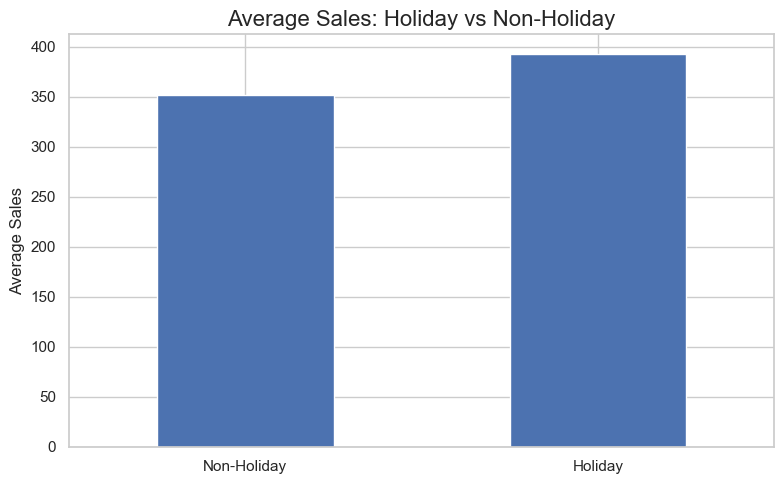

In [41]:
plt.figure(figsize=(8, 5))

holiday_summary["average_sales"].plot(kind="bar")

plt.title("Average Sales: Holiday vs Non-Holiday", fontsize=16)
plt.xlabel("")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3.13 Transaction Activity and Sales

Transaction volume provides an additional measure of store activity. Its relationship with sales is examined to determine whether transaction activity may provide useful forecasting information.

In [42]:
daily_transactions = (
    df.groupby("date")["transactions"]
    .sum()
    .reset_index()
)

sales_transactions = daily_sales[
    ["date", "sales"]
].merge(
    daily_transactions,
    on="date",
    how="left"
)

sales_transactions[["sales", "transactions"]].corr()

,sales,transactions
sales,1.00,0.66
transactions,0.66,1.00


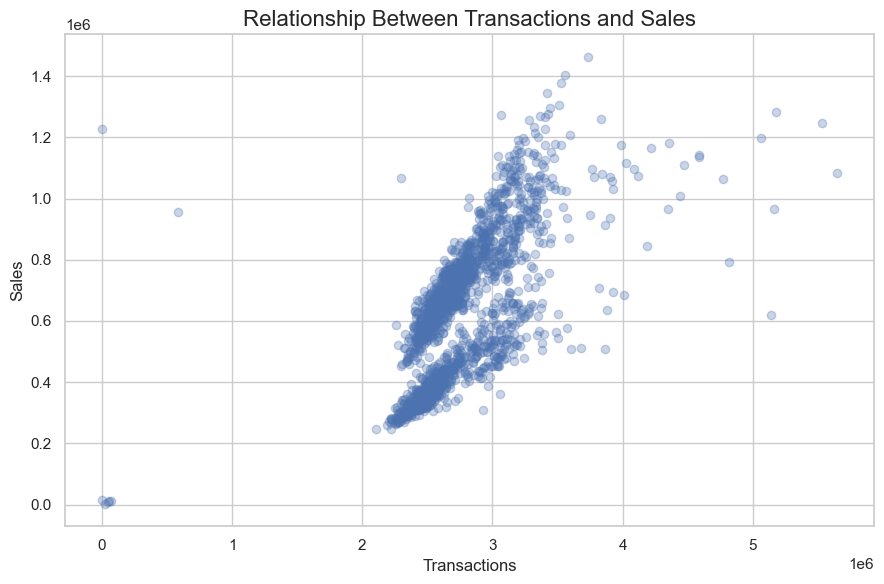

In [43]:
plt.figure(figsize=(9, 6))

plt.scatter(
    sales_transactions["transactions"],
    sales_transactions["sales"],
    alpha=0.3
)

plt.title("Relationship Between Transactions and Sales", fontsize=16)
plt.xlabel("Transactions")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

## 3.14 External Economic Factor: Oil Price

Oil price is examined as an external economic variable that may capture broader economic conditions affecting retail demand.

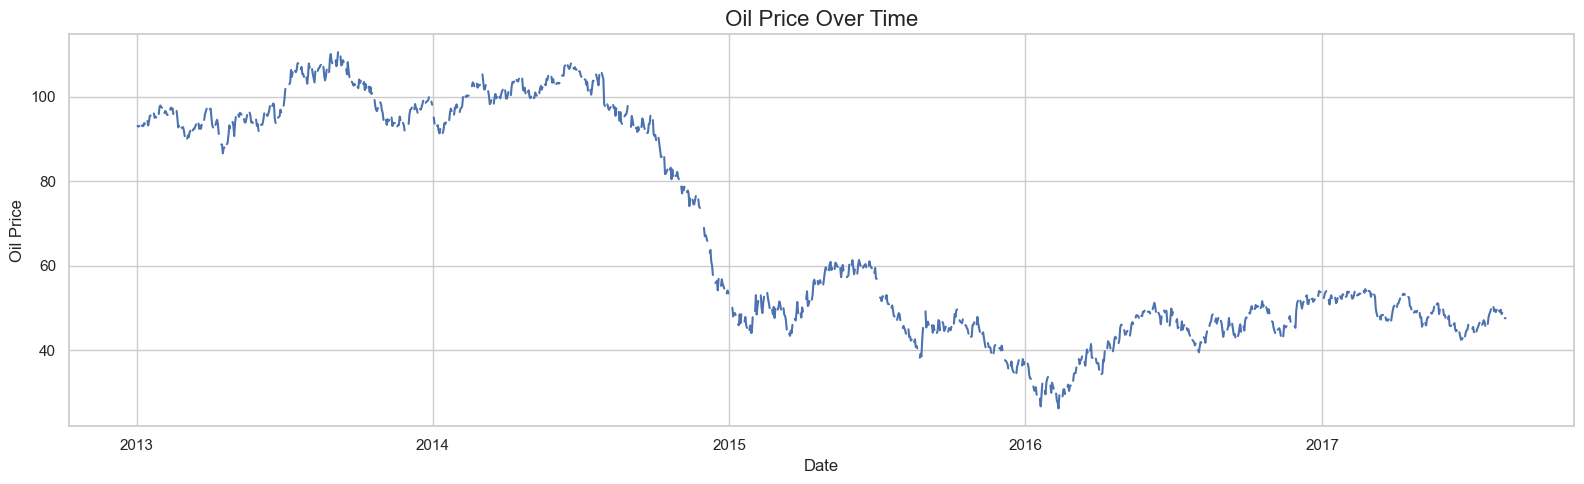

In [44]:
daily_oil = (
    df.groupby("date")["dcoilwtico"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(16, 5))

plt.plot(
    daily_oil["date"],
    daily_oil["dcoilwtico"]
)

plt.title("Oil Price Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.tight_layout()
plt.show()

In [45]:
df[["sales", "dcoilwtico"]].corr()

,sales,dcoilwtico
sales,1.00,-0.08
dcoilwtico,-0.08,1.00


## 3.15 Demand Volatility

Demand variability is assessed across product families to identify segments with relatively stable or volatile sales patterns.

The coefficient of variation is used to compare variability while accounting for differences in average sales volume.

In [46]:
family_volatility = (
    df.groupby("family")["sales"]
    .agg(
        mean_sales="mean",
        std_sales="std"
    )
)

family_volatility["coefficient_of_variation"] = (
    family_volatility["std_sales"]
    / family_volatility["mean_sales"]
)

family_volatility = family_volatility.sort_values(
    "coefficient_of_variation",
    ascending=False
)

family_volatility

,mean_sales,std_sales,coefficient_of_variation
family,,,
BOOKS,0.07,0.55,7.74
SCHOOL AND OFFICE SUPPLIES,2.96,21.75,7.34
BABY CARE,0.11,0.68,6.16
HOME APPLIANCES,0.46,0.97,2.12
FROZEN FOODS,154.77,324.97,2.10
MAGAZINES,2.93,6.01,2.05
LAWN AND GARDEN,6.04,12.28,2.04
PET SUPPLIES,3.92,7.66,1.95
LADIESWEAR,7.16,13.95,1.95


## 3.16 Sales Distribution and Outlier Assessment

The distribution of sales is examined to identify skewness, extreme observations, and potential demand spikes.

Extreme observations are not automatically removed because unusually high demand may represent genuine business events such as promotions or holidays.

In [47]:
sales_distribution = df["sales"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

sales_distribution

count   3,000,888.00
mean          357.78
std         1,102.00
min             0.00
1%              0.00
5%              0.00
25%             0.00
50%            11.00
75%           195.85
95%         1,965.00
99%         5,507.00
max       124,717.00
Name: sales, dtype: float64

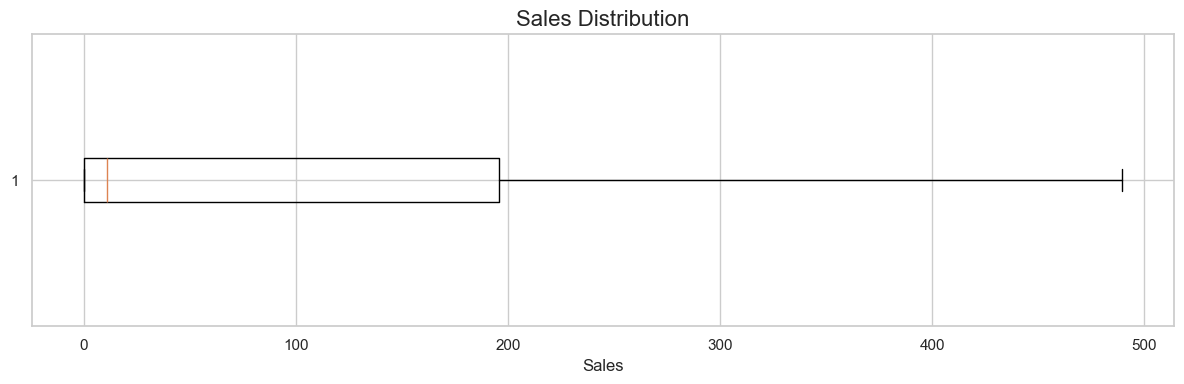

In [48]:
plt.figure(figsize=(12, 4))

plt.boxplot(
    df["sales"],
    vert=False,
    showfliers=False
)

plt.title("Sales Distribution", fontsize=16)
plt.xlabel("Sales")
plt.tight_layout()
plt.show()

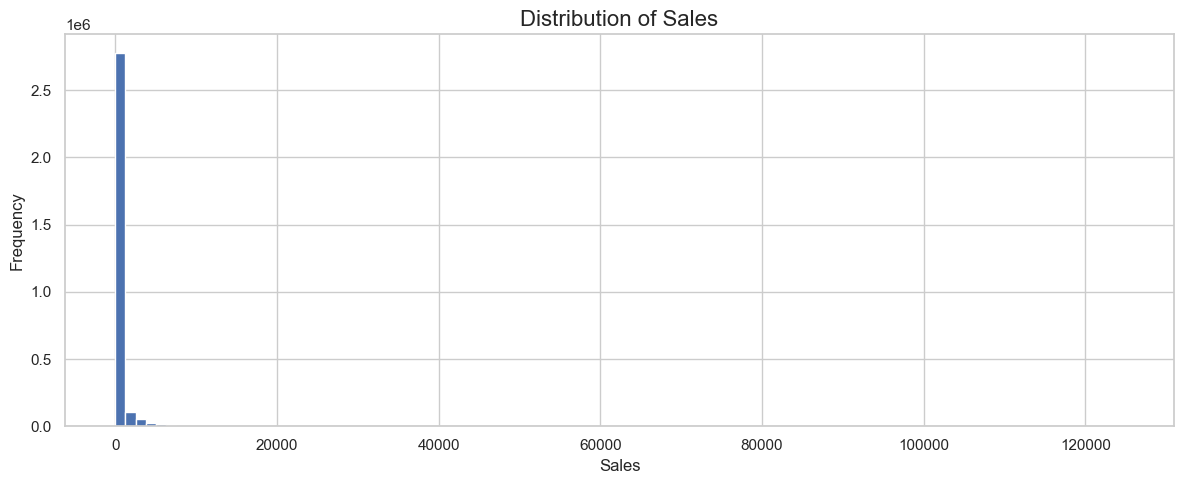

In [49]:
plt.figure(figsize=(12, 5))

plt.hist(
    df["sales"],
    bins=100
)

plt.title("Distribution of Sales", fontsize=16)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 3.17 Relationship Between Numerical Variables

Relationships among key numerical variables are examined to identify potential explanatory signals for demand forecasting.

In [50]:
numeric_features = [
    "sales",
    "onpromotion",
    "transactions",
    "dcoilwtico"
]

correlation_matrix = df[numeric_features].corr()

correlation_matrix

,sales,onpromotion,transactions,dcoilwtico
sales,1.00,0.43,0.21,-0.08
onpromotion,0.43,1.00,0.03,-0.15
transactions,0.21,0.03,1.00,0.02
dcoilwtico,-0.08,-0.15,0.02,1.00


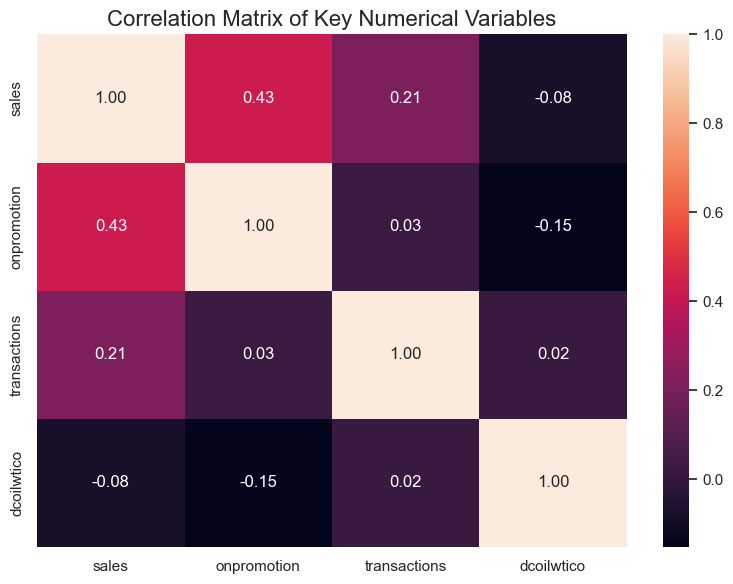

In [51]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of Key Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

## 3.18 EDA Outputs

Key analytical summaries are saved to the project output directory for reproducibility and later use in model evaluation and reporting.

In [52]:
import os

os.makedirs("outputs/charts", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)
os.makedirs("outputs/forecasts", exist_ok=True)

In [53]:
store_sales.to_csv(
    "outputs/tables/store_sales_summary.csv"
)

family_sales.to_csv(
    "outputs/tables/family_sales_summary.csv"
)

annual_total.to_csv(
    "outputs/tables/annual_sales_summary.csv"
)

promotion_summary.to_csv(
    "outputs/tables/promotion_summary.csv"
)

holiday_summary.to_csv(
    "outputs/tables/holiday_summary.csv"
)

family_volatility.to_csv(
    "outputs/tables/family_volatility.csv"
)

correlation_matrix.to_csv(
    "outputs/tables/correlation_matrix.csv"
)

## 3.19 Exploratory Data Analysis Summary

The exploratory analysis provides several important considerations for forecasting model development:

- Retail demand exhibits temporal patterns that require time-based features.
- Weekly and monthly demand patterns indicate the presence of seasonal behaviour.
- Sales volumes differ substantially across stores and product families.
- Promotional activity represents a potential explanatory variable for demand.
- Holiday periods provide additional calendar information that may influence sales.
- Transaction activity provides a complementary measure of store-level demand.
- External economic variables such as oil price may provide additional predictive information.
- Demand volatility differs across product families, suggesting that forecasting performance may vary by segment.
- Extreme sales observations require careful treatment because they may represent genuine demand events rather than data errors.

These findings will guide the feature engineering and forecasting strategy developed in the next stage.